In [1]:
# suppress tensorflow logging, usually not useful unless you are having problems with tensorflow or accessing gpu
# it seems necessary to have this environment variable set before tensorflow is imported, or else it doesn't take effect
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

# imports generally useful throughout the notebook
# usually all imports should happen at the top of a notebook, but in
# these notebooks where the purpose is to show how to use the Keras API
# the relevant imports will happen in the cells where the API is discussed
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import datetime
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# global settings for notebook output and images
plt.rcParams['figure.figsize'] = (8, 8) # set default figure size, 10in by 8in
np.set_printoptions(precision=4, suppress=True)

In [2]:
# import project defined modules / functions used in this notebook
# ensure that the src directory where project modules are found is on
# the PYTHONPATH
import sys
sys.path.append("../src")

# assignment function imports for doctests and github autograding
# these are required for assignment autograding
from nndl import vectorize_samples, plot_history

In [3]:
# if want to restrict to cpu or gpu, configure visible device for rest of notebook to use
dev = tf.config.list_physical_devices()
print('Physical Devices : ', dev)

tf.config.set_visible_devices(dev[0])
#tf.config.set_visible_devices(dev[1])
dev = tf.config.list_logical_devices()
print('Available Devices : ', dev)

Physical Devices :  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Available Devices :  [LogicalDevice(name='/device:CPU:0', device_type='CPU')]


# Chapter 10: Deep Learning for Timeseries

Supporting materials for:

Chollet (2021). *Deep Learning with Python*. 2nd ed. Manning Publications Co.
[Amazon](https://www.amazon.com/Learning-Python-Second-Fran%C3%A7ois-Chollet/dp/1617296864/ref=sr_1_1?crid=32NFM2SBCJVQQ)

In this section we turn to deep learning architecutures for modeling timeseries data.  A timeseries can be any data obtained
via measurements at regular intervals, like the daily price of a stock, hourly electricity consumption, or processing speech input.
A common task for a timeseries is forecasting, predicting what will hapen next in the series.  Recurrent layers are designed
specifically to process and predict time series data.

In [4]:
# reload the data and settings from 10.2 for this notebook
data = pd.read_csv('../data/jena_climate_2009_2016.csv')

# convert the string datetime date stamp to an actual datetime
data['Date Time'] = pd.to_datetime(data['Date Time'], format='%d.%m.%Y %H:%M:%S')

# make a numpy vector of the numeric values, e.g. here raw_data has the temperature, pressure, etc.
# our data has 420451 samples of weather data, with 14 different measurements sampled
numeric_features = data.columns[1:]
raw_data = data[numeric_features].to_numpy()
# also we need just the temperature as a numpy vector, these are the targets of our timeseries prediction
temperature = data['T (degC)'].to_numpy()

# compute number of samples we'll use for each split
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples

# center the mean, use only training samples to determine feature means
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
      
# normalize the range of all data to be +/- 1.0
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

# instantiating dataset for training, validation, and testing
sampling_rate = 6
sequence_length = 120
delay = sampling_rate * (sequence_length + 24 - 1)
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    # the start and end index here are getting the 50%
    start_index=0,
    end_index=num_train_samples
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples
)

## 10.4 Advanced Use of Recurrent Neural Networks

So far you've learned

- What RNNs are and how they work
- What LSTM is and why it works better on long sequences than naive RNN
- How to use Keras RNN layers to process sequence data

In this section we will look at:

- **Recurrent dropout** This is a variant of dropout, used to fight overfitting in recurrent layers.
- **Stacking recurrent layers** This increases the representational power of the model
  (at the cost of higher computational loads).
- **Bidirectional recurrent layers** These present the same information to a recurrent
  network in different ways, increasing accuracy and mitigating forgetting issues.

### 10.4.1 Using recurrent dropout to fight overfitting

Our last LSTM example model on the weather data is probably overfitting
despite only having very few units, the training and validation losses start to
diverge considerably after a few epochs.

You are already familiar with dropout for feedforward networks.

The proper way to use dropout with a recurrent network is to apply the same dropout mask at every timestep, instead of
using a dropout mask that varies randomly from timestep to timestep.

Also in order to regularize the representations
formed by the recurrent gates of layers such as GRU and LSTM, a temporally
constant dropout mask should be applied to the inner recurrent activations of the
layer (a recurrent dropout mask). 

Using the same dropout mask at every timestep
allows the network to properly propagate its learning error through time; a temporally
random dropout mask would disrupt this error signal and be harmful to the
learning process.

Every recurrent layer in Keras has two dropout-related
arguments: dropout, a float specifying the dropout rate for input units of the layer,
and recurrent_dropout, specifying the dropout rate of the recurrent units.

Thanks to dropout we don't have to rely on getting network size right for regularizaiton,
so let's continue with our previous model but use twice as many units, which should, hopefully,
be more expressive.  Because networks being regularized with dropout always take much longer to fully
converge, we'll train the model for five times as many epochs.

**Note**: There is a note in our textbook about RNN runtime performance.  Something I hadn't known
was that recurrent networks can be faster on a multicore CPU than on a GPU.  My experience with running
the next model bears that out.  GPU is quite a bit slower for this model.  But also be warned, that
it taked 50-60 seconds per epoch, so the following example will take some time to complete
training.

In [5]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
# use dropout on recurrent operations inside the LSTM
x = layers.LSTM(32, recurrent_dropout=0.25)(inputs)
# to regularize the dense layer, we also add a dropout layer after teh LSTM
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)

model = keras.Model(inputs, outputs)

callbacks = [keras.callbacks.ModelCheckpoint("../models/jena_lstm_dropout.keras", save_best_only=True)]

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

In [6]:
history = model.fit(train_dataset,
                    epochs=50,
                    validation_data=val_dataset,
                    callbacks=callbacks)

Epoch 1/50


I0000 00:00:1749850679.034219   81684 service.cc:152] XLA service 0x748fd001f940 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749850679.034286   81684 service.cc:160]   StreamExecutor device (0): Host, Default Version
2025-06-13 21:37:59.096687: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


  2/819 ━━━━━━━━━━━━━━━━━━━━ 58s 72ms/step - loss: 139.2123 - mae: 9.7761

I0000 00:00:1749850680.059460   81684 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


819/819 ━━━━━━━━━━━━━━━━━━━━ 64s 75ms/step - loss: 49.8747 - mae: 5.2499 - val_loss: 9.7449 - val_mae: 2.4173
Epoch 2/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 61s 74ms/step - loss: 15.2836 - mae: 3.0384 - val_loss: 9.3431 - val_mae: 2.3685
Epoch 3/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 61s 74ms/step - loss: 14.3851 - mae: 2.9445 - val_loss: 9.2655 - val_mae: 2.3582
Epoch 4/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 59s 72ms/step - loss: 13.8115 - mae: 2.8816 - val_loss: 9.1963 - val_mae: 2.3486
Epoch 5/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 62s 76ms/step - loss: 13.2684 - mae: 2.8267 - val_loss: 9.1524 - val_mae: 2.3430
Epoch 6/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 62s 75ms/step - loss: 13.0492 - mae: 2.7992 - val_loss: 9.1987 - val_mae: 2.3458
Epoch 7/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 62s 75ms/step - loss: 12.7167 - mae: 2.7637 - val_loss: 8.9516 - val_mae: 2.3113
Epoch 8/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 62s 75ms/step - loss: 12.4320 - mae: 2.7324 - val_loss: 9.2152 - val_mae: 2.3486
Epoch 9/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 62s

In [7]:
# get the best model that was checkpointed and evaluate on test data
model = keras.models.load_model('../models/jena_lstm_dropout.keras')
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - loss: 9.9266 - mae: 2.4902
Test MAE: 2.48


(2.0, 3.0)

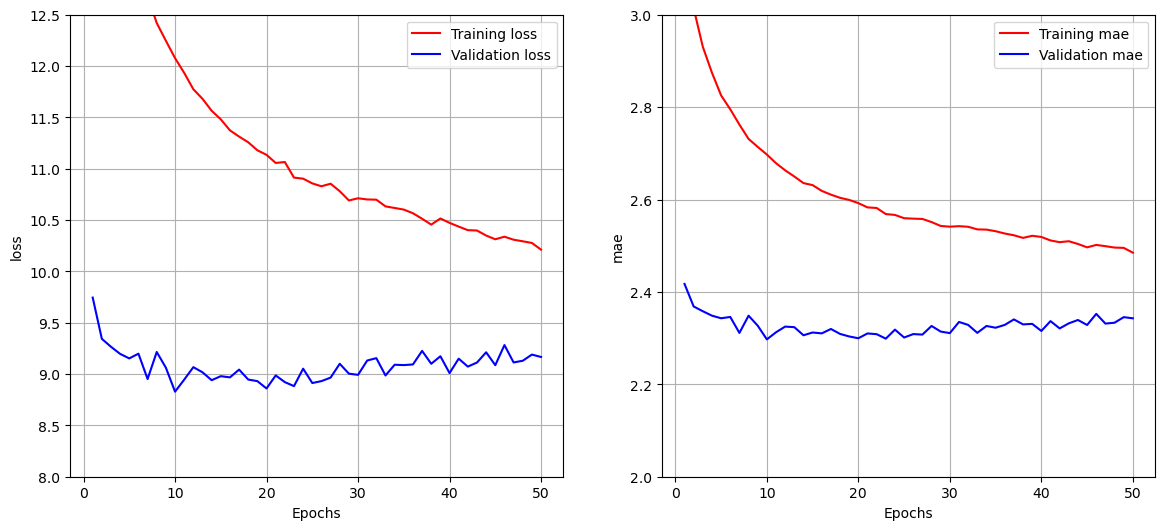

In [13]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history.history, 'loss')
ax_loss.set_ylim([8, 12.5])
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, history.history, 'mae')
ax_acc.set_ylim([2.0, 3.0])

Looking at the learning curves and the test MAE you should usually see (if you can wait long enough) that the results are much better than
we achieved before.  The training and validation loss should not show much signs of overfitting.  You will usually get around a 2.4 MAE on test data.

### 10.4.2 Stacking recurrent layers

Because we're no longer overfitting but seem to have hit a performance
bottleneck, we should consider increasing teh capacity and expressive power of the network.

Increasing network capacity is typically done by increasing the number of units in the layers or adding more layers.

Recurrent layer stacking is a classic way to build
more-powerful recurrent networks.

To stack recurrent layers on top of each other in Keras, all intermediate layers should
return their full sequence of outputs (a rank-3 tensor) rather than their output at the last
timestep. As you’ve already learned, this is done by specifying return_sequences=True.

In the following example we'll try to improve our performance by stacking two dropout-regularized
recurrent layers.  For a change, we'll use Gated Recurrent Unit (GRU) layers instead of LSTM.
GRU is very similar to LSTM, you can think of it as a slightly simpler streamlined version of the
LSTM architecture.

In [14]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.GRU(32, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = layers.GRU(32, recurrent_dropout=0.5)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)

model = keras.Model(inputs, outputs)

callbacks = [keras.callbacks.ModelCheckpoint("../models/jena_stacked_gru_dropout.keras", save_best_only=True)
]

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

In [ ]:
history = model.fit(train_dataset,
                    epochs=50,
                    validation_data=val_dataset,
                    callbacks=callbacks)

Epoch 1/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 124s 146ms/step - loss: 42.4580 - mae: 4.8009 - val_loss: 9.1382 - val_mae: 2.3286
Epoch 2/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 118s 144ms/step - loss: 14.3746 - mae: 2.9394 - val_loss: 8.9527 - val_mae: 2.3205
Epoch 3/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 119s 145ms/step - loss: 13.5049 - mae: 2.8459 - val_loss: 8.5880 - val_mae: 2.2717
Epoch 4/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 118s 144ms/step - loss: 12.9589 - mae: 2.7858 - val_loss: 8.7309 - val_mae: 2.2959
Epoch 5/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 118s 144ms/step - loss: 12.6127 - mae: 2.7523 - val_loss: 8.6688 - val_mae: 2.2914
Epoch 6/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 118s 144ms/step - loss: 12.1721 - mae: 2.7081 - val_loss: 8.4570 - val_mae: 2.2455
Epoch 7/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 121s 148ms/step - loss: 11.9985 - mae: 2.6867 - val_loss: 8.6066 - val_mae: 2.2680
Epoch 8/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 117s 143ms/step - loss: 11.6985 - mae: 2.6554 - val_loss: 8.3974 - val_mae: 2.2375
Epoch 9/50
819/8

In [ ]:
model = keras.models.load_model("../models/jena_stacked_gru_dropout.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

In [ ]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history.history, 'loss')
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, history.history, 'mae')

You usually should see some improvement over the single LSTM layer here, if you are able to train this example.  Typically
a test MAE of 2.4 or a bit below.  The layer maybe improved the result a bit, but not dramatically.

### 10.4.3 Using bidirectional RNNs

The last technique we'll look at in this section is the **bidirectional RNN**.  A bidirectional RNN is a common
RNN variant that can offer greater performance than a regular RNN on certain tasks.  It's frequently used in natural
language processing (NLP).

A bidirectional RNN exploits the order sensitivity of RNNs: it uses two regular RNNs, such as the GRU or LSTM layers you have just seen.
One processes the input sequence chronologically, and the other in the reverse direction, antichronologically.

By processing a sequence both ways, a bidirectional RNN can catch patterns that may be overlooked by a unidirectional RNN.


To instantiate a bidirectional RNN in Keras use the `Bidirectional` layer, which takes as its first argument
a recurrent layer instance.

In [ ]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Bidirectional(layers.LSTM(16))(inputs)
outputs = layers.Dense(1)(x)

model = keras.Model(inputs, outputs)

In [ ]:
callbacks = [keras.callbacks.ModelCheckpoint("../models/jena_bidirectional.keras", save_best_only=True)]

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

In [ ]:
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset)

In [ ]:
# get the best model that was checkpointed and evaluate on test data
model = keras.models.load_model('../models/jena_bidirectional.keras')
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

In [ ]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history.history, 'loss')
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, history.history, 'mae')

You'll find that it doesn't perform as well as the plain LSTM layer.  It is easy to understand why for this data, all of the predictive capacity
comes from the series near the end where we want to predict, not the beginning.  So the weather prediction example is not one of the classes of
problems that can benefit from a bidirectional RNN.

### 10.4.4 Going even further

There are many other things we could try to improve perforance on the temperature-forecasting problem:

- Adjust the number of units in each recurrent layer in the stacked setup, as well
  as the amount of dropout. The current choices are largely arbitrary and thus
  probably suboptimal.
- Adjust the learning rate used by the RMSprop optimizer, or try a different
  optimizer.
- Try using a stack of Dense layers as the regressor on top of the recurrent layer,
  instead of a single Dense layer.
- Improve the input to the model: try using longer or shorter sequences or a different
  sampling rate, or start doing feature engineering.

In my experience, improving on the no-learning baseline by about 10% is likely
the best you can do with this dataset. This isn’t so great, but these results make sense:
while near-future weather is highly predictable if you have access to data from a wide
grid of different locations, it’s not very predictable if you only have measurements
from a single location. The evolution of the weather where you are depends on current
weather patterns in surrounding locations.

## Summary

<font color='blue'>
    
- The proper way to use **Recurrent dropout** is to use the same dropout mask at every timestep.
  - Keras provides `recurrent_dropout` parameter to specify dropout regularization for recurrent layers.
- **Stacking recurrent layers** is a way to increase representational capacity of a recurrent network, but all
  intermediate layers must return their full sequence of outputs, in Keras by specifying `return_sequences=True`
- **Bidirectional recurrent layers** are great for text data or any other kind of data where order matters, yet
  which order you use doesn't matter.